<a href="https://colab.research.google.com/github/HoangNguyennnnnnn/Kaggle/blob/main/Human_Bone_Fractures_Image_Dataset_(HBFMID).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Source: "https://www.kaggle.com/code/sehriyarmemmedli/bone-fractures"

In [15]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
orvile_human_bone_fractures_image_dataset_hbfmid_path = kagglehub.dataset_download('orvile/human-bone-fractures-image-dataset-hbfmid')

print('Data source import complete.')

Data source import complete.


In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/human-bone-fractures-image-dataset-hbfmid/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/README.roboflow.txt
/kaggle/input/human-bone-fractures-image-dataset-hbfmid/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/data.yaml
/kaggle/input/human-bone-fractures-image-dataset-hbfmid/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/valid/labels/50_jpg.rf.947f4c229bee0c92a4e6a9ac5a57db6d.txt
/kaggle/input/human-bone-fractures-image-dataset-hbfmid/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/valid/labels/223_jpg.rf.b39b48080f6edfe1b0bd3a6b2837f7ef.txt
/kaggle/input/human-bone-fractures-image-dataset-hbfmid/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/valid/labels/246_jpg.rf.5761ae00666b864051b675665c155d87.txt
/kaggle/input/human-bone-fractures-image-dataset-hbfmid/Human Bone Fractures Multi-modal Image Dataset 

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import pathlib

In [18]:
my_dir = "/kaggle/input/human-bone-fractures-image-dataset-hbfmid/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection"

In [19]:
!pip install -q ultralytics supervision

In [20]:
train_images_dir = pathlib.Path(my_dir) / "train" / "images"
train_labes_dir = pathlib.Path(my_dir) / "train" / "labels"
train_images = list(train_images_dir.glob("*.jpg"))

In [21]:
class_names = ['Comminuted', 'Greenstick', 'Healthy', 'Linear', 'Oblique Displaced', 'Oblique', 'Segmental', 'Spiral', 'Transverse Displaced', 'Transverse']

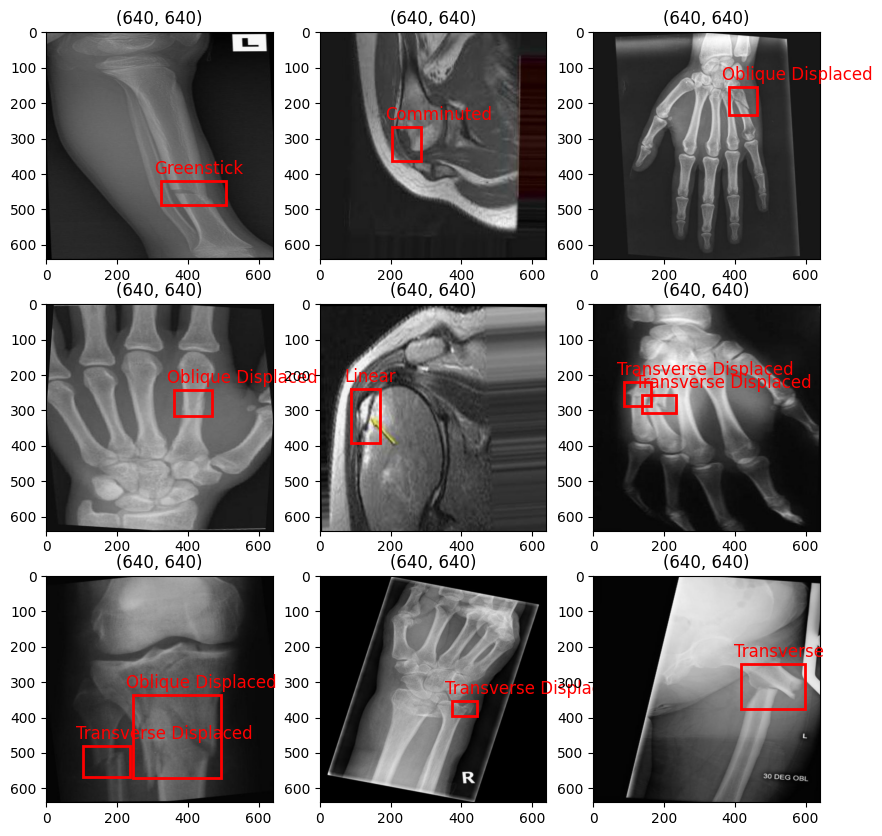

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    img = Image.open(train_images[i])
    ax.imshow(img)
    ax.set_title(img.size)
    # ax.axis("off")

    label_path = train_labes_dir / f"{train_images[i].stem}.txt"
    if label_path.exists():
        with open(label_path, "r") as f:
            lines = f.readlines()

        img_width, img_height = img.size
        for line in lines:
            values = line.strip().split()
            class_id = int(values[0])
            x_center, y_center, width, height = map(float, values[1:])

            x1 = int((x_center - width / 2) * img_width)
            y1 = int((y_center - height / 2) * img_height)

            box_width = int(width * img_width)
            box_height = int(height * img_height)

            rect = patches.Rectangle((x1, y1), box_width, box_height, linewidth=2, edgecolor="r", facecolor="none")
            ax.add_patch(rect)
            ax.text(x1-20, y1-20, class_names[class_id], color="r", fontsize=12)

In [23]:
!yolo \
  task=detect \
  mode=train \
  data="/kaggle/input/human-bone-fractures-image-dataset-hbfmid/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/data.yaml" \
  model=yolov8n.pt \
  epochs=100 \
  batch=4 \
  device=0 \
  patience=20 \
  verbose=True


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
100% 6.25M/6.25M [00:00<00:00, 106MB/s]
Ultralytics 8.3.122 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/kaggle/input/human-bone-fractures-image-dataset-hbfmid/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/data.yaml, epochs=100, time=None, patience=20, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze

In [24]:
import supervision as sv
from ultralytics import YOLO

In [25]:
model = YOLO("runs/detect/train/weights/best.pt")
image = Image.open(train_images[0])
results = model(image)[0]
detections = sv.Detections.from_ultralytics(results)


0: 640x640 1 Greenstick, 10.3ms
Speed: 3.8ms preprocess, 10.3ms inference, 142.0ms postprocess per image at shape (1, 3, 640, 640)


In [26]:
label_annotator = sv.LabelAnnotator()
box_annotator = sv.BoxAnnotator()

annotated_frame = box_annotator.annotate(scene=image.copy(),detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_frame, detections=detections)

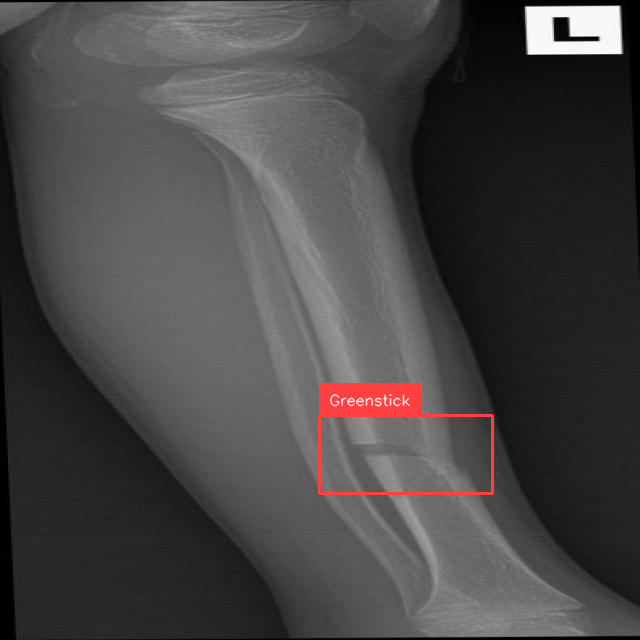

In [27]:
display(annotated_frame)